# Early Sepsis Prediction — HistGB Model
**Paper:** Wang et al., *Diagnostics* 2025, 15, 2727  
**Algorithm:** Histogram-based Gradient Boosting (HistGB) only  
**Data:** CHoRUS AIM-AHEAD60 subset — 3 configurations: EHR structured / Waveform / Combined

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports  (HistGB ONLY)
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
from scipy import stats

warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully')
print('Algorithm : HistGradientBoostingClassifier (sklearn)')


All libraries loaded successfully
Algorithm : HistGradientBoostingClassifier (sklearn)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Data
# Paper: CHoRUS AIM-AHEAD60 subset, 11,312 patients, 19.85% sepsis
# Your actual data has many more columns than the synthetic demo —
# update DATA_PATH to point to your real CSV.
# ─────────────────────────────────────────────────────────────────────────────

DATA_PATH = '/content/Dataset.csv'   # ← CHANGE THIS to your actual file path
df=pd.read_csv('/content/Dataset.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

# try:
#     df_raw = pd.read_csv(DATA_PATH)
#     print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
#     print(f'Columns: {list(df_raw.columns)}')

# except FileNotFoundError:
#     print('Data file not found — generating synthetic demo data.')
#     print('Replace DATA_PATH above with your actual file path.\n')

#     # The synthetic data generation code has been removed as per user request.
#     # It was previously within this 'except' block.
#     raise FileNotFoundError("Please upload 'Dataset.csv' to /content/ or provide the correct path.")

# print(f'\nUnique patients   : {df_raw["Patient_ID"].nunique():,}')
# print(f'Sepsis prevalence : {df_raw.groupby("Patient_ID")["SepsisLabel"].max().mean()*100:.2f}%')
# print(f'Paper reference   : 11,312 patients, 19.85% sepsis')
# df_raw.head(3)


Loaded: 31,526 rows × 44 columns
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Table 1: Statistical Comparison of Sepsis vs Non-Sepsis
# Paper Section 2.9: Student's t-test (continuous), chi-square (categorical)
# ─────────────────────────────────────────────────────────────────────────────

# One row per patient (first hour)
df_pt = df.sort_values(['Patient_ID', 'Hour']).groupby('Patient_ID').first().reset_index()

sep_group    = df_pt[df_pt['SepsisLabel'] == 1]
nonsep_group = df_pt[df_pt['SepsisLabel'] == 0]
n_sep, n_nonsep = len(sep_group), len(nonsep_group)

print('=' * 75)
print(f'  TABLE 1 — General Characteristics of the Study Population')
print(f'  Sepsis n={n_sep:,}  |  Non-Sepsis n={n_nonsep:,}')
print('=' * 75)

# Continuous variables: t-test
cont_vars = [v for v in ['Age','HR','Resp','SBP','MAP','DBP','Temp','O2Sat',
                          'Lactate','WBC','Platelets','Creatinine',
                          'Bilirubin_direct','BUN','Hgb','Hct']
             if v in df_pt.columns]

print(f'\n  Continuous variables (Student\'s t-test):')
print(f'  {"Variable":<22} {"Sepsis Mean(SD)":>20} {"Non-Sepsis Mean(SD)":>22} {"p-value":>10}')
print('  ' + '-' * 77)
for var in cont_vars:
    s  = sep_group[var].dropna()
    ns = nonsep_group[var].dropna()
    if len(s) < 2 or len(ns) < 2:
        continue
    _, p = stats.ttest_ind(s, ns, equal_var=False)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {var:<22} {s.mean():>8.2f} ({s.std():.2f})     '
          f'{ns.mean():>8.2f} ({ns.std():.2f})     {p:>10.4f} {sig}')

# Categorical variables: chi-square
cat_vars = [v for v in ['Gender','Race','Ethnicity','MaritalStatus']
            if v in df_pt.columns]
if cat_vars:
    print(f'\n  Categorical variables (Pearson chi-square test):')
    print(f'  {"Variable":<22} {"Sepsis n(%)":>18} {"Non-Sepsis n(%)":>20} {"p-value":>10}')
    print('  ' + '-' * 72)
    for var in cat_vars:
        s_v  = sep_group[var].dropna()
        ns_v = nonsep_group[var].dropna()
        if len(s_v) < 2 or len(ns_v) < 2:
            continue
        ct = pd.crosstab(
            pd.concat([s_v.rename('val'), ns_v.rename('val')]),
            pd.concat([pd.Series(['Sepsis']*len(s_v)),
                       pd.Series(['NonSepsis']*len(ns_v))], ignore_index=True)
        )
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, dof, _ = stats.chi2_contingency(ct)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            print(f'  {var:<22} {len(s_v):>6} ({len(s_v)/n_sep*100:.1f}%)     '
                  f'{len(ns_v):>6} ({len(ns_v)/n_nonsep*100:.1f}%)     {p:>10.4f} {sig}')

print('\n  Significance: * p<0.05  ** p<0.01  *** p<0.001')

  TABLE 1 — General Characteristics of the Study Population
  Sepsis n=10  |  Non-Sepsis n=808

  Continuous variables (Student's t-test):
  Variable                    Sepsis Mean(SD)    Non-Sepsis Mean(SD)    p-value
  -----------------------------------------------------------------------------
  Age                       71.96 (14.34)        63.09 (15.85)         0.0830 
  HR                        79.65 (19.48)        85.32 (17.53)         0.3830 
  Resp                      18.15 (2.47)        17.09 (5.10)         0.2150 
  SBP                      117.44 (24.12)       124.55 (22.19)         0.4334 
  MAP                       74.45 (16.10)        81.80 (15.93)         0.1843 
  DBP                       55.75 (7.09)        62.46 (12.50)         0.1540 
  Temp                      36.79 (0.92)        36.56 (0.86)         0.4523 
  O2Sat                     97.75 (2.49)        97.96 (3.72)         0.8021 
  Lactate                    2.78 (1.56)         2.35 (2.12)         0.6260 

In [4]:
# NEW CELL — Clinical Data Cleaning (Paper Section 2.2)
def apply_clinical_caps(df):
    """Applies clinical plausibility caps as defined in the paper."""
    df = df.copy()

    # Paper specifies capping Age at 90
    df['Age'] = df['Age'].clip(upper=90)

    # Clinical Vitals Caps
    if 'HR' in df.columns:    df['HR'] = df['HR'].clip(40, 250)
    if 'Resp' in df.columns:  df['Resp'] = df['Resp'].clip(0, 40)
    if 'SBP' in df.columns:   df['SBP'] = df['SBP'].clip(0, 300)
    if 'Temp' in df.columns:  df['Temp'] = df['Temp'].clip(25, 50)

    # Filter for First-Hour only as per paper title [cite: 1]
    df = df[df['Hour'] <= 1]

    return df

df_cleaned = apply_clinical_caps(df)
print("Clinical caps applied and data filtered to the first hour.")

# NEW CELL — Waveform Feature Engineering (Paper Section 2.4)
def extract_waveform_stats(df):
    """Calculates Mean, Min, and Max for waveform variables as per paper."""
    vitals = ['HR', 'Resp', 'SBP', 'Temp']

    # Group by Patient to get summary stats for the first hour
    waveform_stats = df.groupby('Patient_ID')[vitals].agg(['mean', 'min', 'max'])

    # Flatten multi-index columns (e.g., HR_mean, HR_min, etc.)
    waveform_stats.columns = ['_'.join(col).strip() for col in waveform_stats.columns.values]
    return waveform_stats.reset_index()

df_waveform_features = extract_waveform_stats(df_cleaned)


Clinical caps applied and data filtered to the first hour.


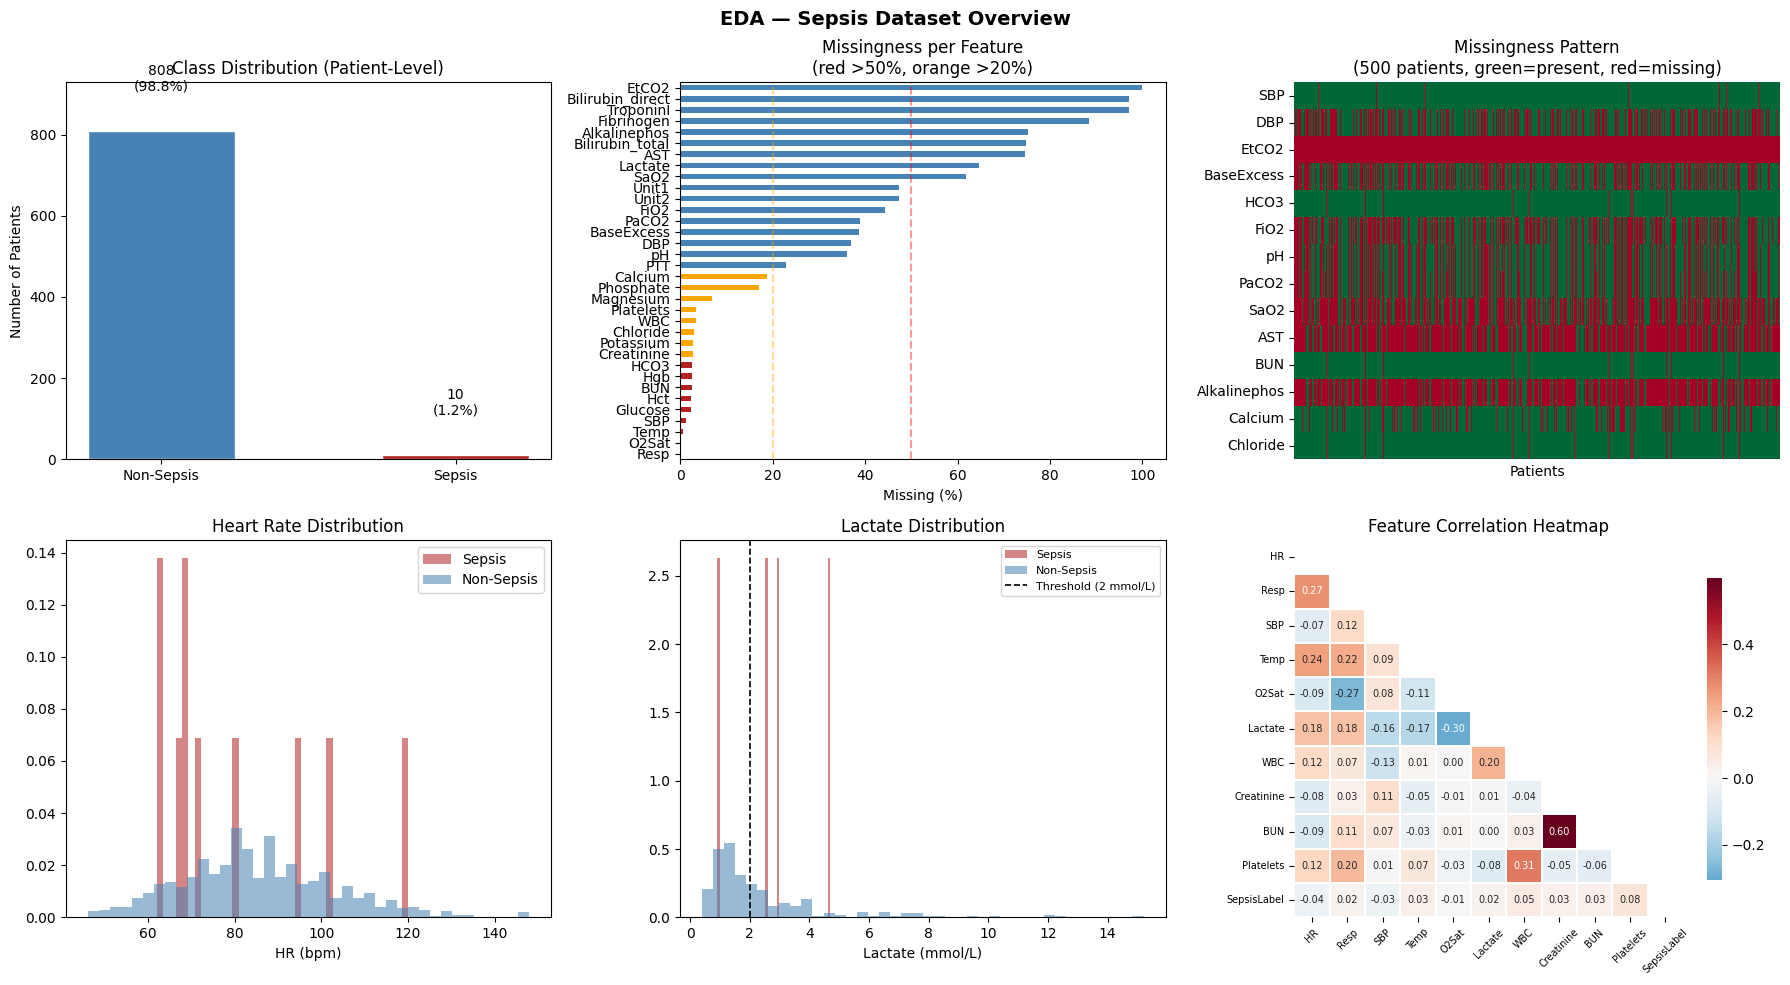

EDA plot saved → histgb_eda.png


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Exploratory Data Analysis
# Covers: class imbalance, missingness pattern, distributions, correlations
# Paper Section 2.4–2.5: missing data retained as informative signal
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Sepsis Dataset Overview', fontsize=14, fontweight='bold')

# 1. Class imbalance (patient-level)
ax = axes[0, 0]
label_counts = df_pt['SepsisLabel'].value_counts()
bars = ax.bar(['Non-Sepsis', 'Sepsis'], label_counts.values,
              color=['steelblue', 'firebrick'], edgecolor='white', width=0.5)
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({count/label_counts.sum()*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Class Distribution (Patient-Level)')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, label_counts.max() * 1.15)

# 2. Missing value % per feature (EHR features, patient-level)
ax = axes[0, 1]
num_cols = [c for c in df_pt.columns
            if df_pt[c].dtype in [np.float64, np.int64, float, int]
            and c not in ['Patient_ID', 'SepsisLabel', 'Gender', 'Hour']]
miss_pct  = df_pt[num_cols].isna().mean().sort_values(ascending=False) * 100
miss_pct  = miss_pct[miss_pct > 0]
colors    = ['firebrick' if v > 50 else 'orange' if v > 20 else 'steelblue'
             for v in miss_pct]
miss_pct.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_xlabel('Missing (%)')
ax.set_title('Missingness per Feature\n(red >50%, orange >20%)')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.4)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.4)

# 3. Missingness heatmap (sample of 500 patients — pattern analysis)
ax = axes[0, 2]
sample_cols = [c for c in num_cols if df_pt[c].isna().mean() > 0.01][:14]
df_miss     = df_pt[sample_cols].head(500).isna().astype(int)
sns.heatmap(df_miss.T, ax=ax, cmap='RdYlGn_r', cbar=False,
            xticklabels=False, yticklabels=True)
ax.set_title('Missingness Pattern\n(500 patients, green=present, red=missing)')
ax.set_xlabel('Patients')

# 4. Key vital signs distribution: Sepsis vs Non-Sepsis
ax = axes[1, 0]
for label, color, name in [(1, 'firebrick', 'Sepsis'), (0, 'steelblue', 'Non-Sepsis')]:
    d = df_pt[df_pt['SepsisLabel'] == label]['HR'].dropna()
    ax.hist(d, bins=40, alpha=0.55, color=color, label=name, density=True)
ax.set_title('Heart Rate Distribution')
ax.set_xlabel('HR (bpm)')
ax.legend()

# 5. Lactate distribution: Sepsis vs Non-Sepsis
ax = axes[1, 1]
for label, color, name in [(1, 'firebrick', 'Sepsis'), (0, 'steelblue', 'Non-Sepsis')]:
    d = df_pt[df_pt['SepsisLabel'] == label]['Lactate'].dropna()
    if len(d) > 0:
        ax.hist(d, bins=40, alpha=0.55, color=color, label=name, density=True)
ax.set_title('Lactate Distribution')
ax.set_xlabel('Lactate (mmol/L)')
ax.axvline(x=2.0, color='black', linestyle='--', linewidth=1.2,
           label='Threshold (2 mmol/L)')
ax.legend(fontsize=8)

# 6. Correlation heatmap of numeric EHR features
ax = axes[1, 2]
corr_cols = [c for c in ['HR','Resp','SBP','Temp','O2Sat',
                           'Lactate','WBC','Creatinine','BUN','Platelets']
             if c in df_pt.columns]
corr = df_pt[corr_cols + ['SepsisLabel']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Feature Correlation Heatmap')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/histgb_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved → histgb_eda.png')


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Preprocessing
# Paper Section 2.4: outlier capping only — NO imputation
# Missing values are retained as informative signal (Section 2.9)
# Categorical encoding: label-encode Race/Ethnicity/MaritalStatus
#   (paper Table 1 includes these demographics)
# ─────────────────────────────────────────────────────────────────────────────

def preprocess(df):
    df = df.copy()

    # ── Outlier capping (paper Section 2.4) ──────────────────────────────────
    if 'Age'  in df.columns: df['Age']  = df['Age'].clip(upper=90)
    if 'HR'   in df.columns: df['HR']   = df['HR'].clip(upper=250)
    if 'Resp' in df.columns: df['Resp'] = df['Resp'].clip(upper=40)
    if 'SBP'  in df.columns: df['SBP']  = df['SBP'].clip(upper=300)
    if 'Temp' in df.columns:
        if df['Temp'].dropna().mean() > 45:   # Fahrenheit → Celsius
            df['Temp'] = (df['Temp'] - 32) * 5 / 9
        df['Temp'] = df['Temp'].clip(lower=25, upper=50)
    if 'O2Sat'   in df.columns: df['O2Sat']   = df['O2Sat'].clip(lower=0, upper=100)
    if 'Lactate' in df.columns: df['Lactate'] = df['Lactate'].clip(lower=0)
    if 'WBC'     in df.columns: df['WBC']     = df['WBC'].clip(lower=0)
    if 'Platelets' in df.columns: df['Platelets'] = df['Platelets'].clip(lower=0)

    # ── Categorical encoding (Race / Ethnicity / MaritalStatus) ──────────────
    # Paper Table 1 includes these variables in the demographic description.
    # HistGB requires numeric inputs — label-encode while preserving NaN.
    for col in ['Race', 'Ethnicity', 'MaritalStatus']:
        if col in df.columns:
            le = LabelEncoder()
            non_null = df[col].notna()
            df.loc[non_null, col] = le.fit_transform(df.loc[non_null, col].astype(str))
            df[col] = pd.to_numeric(df[col], errors='coerce')  # NaN rows stay NaN

    return df

df = preprocess(df)

print('Preprocessing complete:')
print('  Outlier capping  → Age≤90, HR≤250, Resp≤40, SBP≤300, Temp∈[25,50]°C')
print('  Categorical cols → Race, Ethnicity, MaritalStatus label-encoded (NaN preserved)')
print('  Missing values   → RETAINED (not imputed) — HistGB handles NaN natively')
print()
print('Post-processing stats (sample):')
for col in ['Age', 'HR', 'Resp', 'SBP', 'Temp', 'Lactate', 'WBC', 'Race']:
    if col in df.columns:
        s = df[col]
        print(f'  {col:<22}: min={s.min():.1f}  max={s.max():.1f}  missing={s.isna().mean()*100:.1f}%')

Preprocessing complete:
  Outlier capping  → Age≤90, HR≤250, Resp≤40, SBP≤300, Temp∈[25,50]°C
  Categorical cols → Race, Ethnicity, MaritalStatus label-encoded (NaN preserved)
  Missing values   → RETAINED (not imputed) — HistGB handles NaN natively

Post-processing stats (sample):
  Age                   : min=18.9  max=89.0  missing=0.0%
  HR                    : min=34.0  max=167.0  missing=7.9%
  Resp                  : min=1.0  max=40.0  missing=10.4%
  SBP                   : min=39.0  max=229.0  missing=15.5%
  Temp                  : min=32.8  max=41.1  missing=65.8%
  Lactate               : min=0.4  max=24.0  missing=96.7%
  WBC                   : min=0.4  max=71.4  missing=92.5%


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Feature Definitions (paper Section 2.5)
# EHR: demographics + initial vital signs + laboratory results
# Waveform: mean/min/max of continuous vitals over first hour
# Combined: EHR + Waveform
# ─────────────────────────────────────────────────────────────────────────────

# ── Structured EHR features ──────────────────────────────────────────────────
# Paper: "demographics: age and sex; initial vital signs: HR, RR, SBP, SpO2, Temp;
#  laboratory results: lactate, band count, platelet, creatinine, bilirubin, neutrophil"
# Race/Ethnicity/MaritalStatus included per paper Table 1 demographic characterisation
DEMO_FEATURES  = [c for c in ['Age', 'Gender', 'Race', 'Ethnicity', 'MaritalStatus']
                  if c in df.columns]
VITAL_FEATURES = [c for c in ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
                  if c in df.columns]
LAB_FEATURES   = [c for c in ['Lactate', 'WBC', 'Platelets', 'Creatinine',
                               'Bilirubin_direct', 'BUN', 'Hgb', 'Hct',
                               'PTT', 'Fibrinogen', 'Troponin',
                               'Glucose', 'Calcium', 'Potassium', 'Chloride']
                  if c in df.columns]
EHR_FEATURES   = DEMO_FEATURES + VITAL_FEATURES + LAB_FEATURES

# ── Waveform features ────────────────────────────────────────────────────────
# Paper: "continuous monitoring data for HR, RR, SBP, Temp — summarized by
#  mean, minimum, and maximum over first hour"
WAVEFORM_VITALS = [c for c in ['HR', 'Resp', 'SBP', 'Temp'] if c in df.columns]

LABEL_COL   = 'SepsisLabel'
PATIENT_COL = 'Patient_ID'
HOUR_COL    = 'Hour'

print('Feature Configuration (paper Section 2.5):')
print(f'  Demographics  : {DEMO_FEATURES}')
print(f'  Vital signs   : {VITAL_FEATURES}')
print(f'  Lab values    : {LAB_FEATURES}')
print(f'  Total EHR     : {len(EHR_FEATURES)} features')
print(f'  Waveform base : {WAVEFORM_VITALS} × (mean/min/max + per-timepoint)')
print()
print('Missing value policy: missingness retained — HistGB handles NaN natively')


Feature Configuration (paper Section 2.5):
  Demographics  : ['Age', 'Gender']
  Vital signs   : ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
  Lab values    : ['Lactate', 'WBC', 'Platelets', 'Creatinine', 'Bilirubin_direct', 'BUN', 'Hgb', 'Hct', 'PTT', 'Fibrinogen', 'Glucose', 'Calcium', 'Potassium', 'Chloride']
  Total EHR     : 23 features
  Waveform base : ['HR', 'Resp', 'SBP', 'Temp'] × (mean/min/max + per-timepoint)

Missing value policy: missingness retained — HistGB handles NaN natively


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Build per-patient EHR / Waveform / Combined datasets
# Paper Section 2.5: EHR → first available value within first hour
#                    Waveform → mean, min, max + per-timepoint readings
# ─────────────────────────────────────────────────────────────────────────────

def build_ehr_dataset(df, ehr_features, label_col, patient_col, hour_col):
    df_s   = df.sort_values([patient_col, hour_col])
    labels = df_s.groupby(patient_col)[label_col].max()
    avail  = [f for f in ehr_features if f in df.columns]
    first_v = df_s.groupby(patient_col)[avail].first()
    return first_v.join(labels)


def build_waveform_dataset(df, waveform_vitals, label_col, patient_col, hour_col):
    df_s   = df.sort_values([patient_col, hour_col])
    labels = df_s.groupby(patient_col)[label_col].max()
    avail  = [v for v in waveform_vitals if v in df.columns]

    agg = df_s.groupby(patient_col)[avail].agg(['mean', 'min', 'max'])
    agg.columns = ['_'.join(c) for c in agg.columns]

    # Per-timepoint (RR_1 ... RR_5 naming matching paper Figure 2B)
    for v in avail:
        for h in sorted(df_s[hour_col].dropna().unique()):
            h = int(h)
            if h > 6:
                continue
            col_name  = f'{v}_{h}'
            hour_vals = df_s[df_s[hour_col] == h].set_index(patient_col)[v]
            agg[col_name] = agg.index.map(hour_vals)

    return agg.join(labels)


print('Building 3 datasets (EHR / Waveform / Combined)...')
df_ehr  = build_ehr_dataset(df, EHR_FEATURES, LABEL_COL, PATIENT_COL, HOUR_COL)
df_wave = build_waveform_dataset(df, WAVEFORM_VITALS, LABEL_COL, PATIENT_COL, HOUR_COL)
df_combined = (df_ehr.drop(columns=[LABEL_COL])
               .join(df_wave.drop(columns=[LABEL_COL]))
               .join(df_ehr[LABEL_COL]))

for name, df_ in [('EHR', df_ehr), ('Waveform', df_wave), ('Combined', df_combined)]:
    n_sep = int(df_[LABEL_COL].sum())
    X     = df_.drop(columns=[LABEL_COL])
    print(f'  {name:<10}: {df_.shape[0]:,} patients × {X.shape[1]} features  |  '
          f'{n_sep:,} sepsis ({n_sep/len(df_)*100:.2f}%)  |  '
          f'avg missing {X.isna().mean().mean()*100:.1f}%')


Building 3 datasets (EHR / Waveform / Combined)...
  EHR       : 818 patients × 23 features  |  67 sepsis (8.19%)  |  avg missing 15.5%
  Waveform  : 818 patients × 40 features  |  67 sepsis (8.19%)  |  avg missing 18.9%
  Combined  : 818 patients × 63 features  |  67 sepsis (8.19%)  |  avg missing 17.6%


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Stratified 70/30 Train/Test Split (paper Section 2.6)
# ─────────────────────────────────────────────────────────────────────────────

def split_dataset(df, label_col, test_size=0.3, random_state=42):
    X = df.drop(columns=[label_col])
    y = df[label_col]
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state, stratify=y)

splits = {}
for name, df_ in [('EHR', df_ehr), ('Waveform', df_wave), ('Combined', df_combined)]:
    X_tr, X_te, y_tr, y_te = split_dataset(df_, LABEL_COL)
    splits[name] = (X_tr, X_te, y_tr, y_te)
    print(f'  {name:<10}: Train={len(X_tr):,} ({y_tr.mean()*100:.2f}% sep)  |  '
          f'Test={len(X_te):,} ({y_te.mean()*100:.2f}% sep)')

print('\n70/30 stratified splits — sepsis rate preserved in both sets')


  EHR       : Train=572 (8.22% sep)  |  Test=246 (8.13% sep)
  Waveform  : Train=572 (8.22% sep)  |  Test=246 (8.13% sep)
  Combined  : Train=572 (8.22% sep)  |  Test=246 (8.13% sep)

70/30 stratified splits — sepsis rate preserved in both sets


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Class Imbalance Weighting
# Paper Section 2.6: algorithm-specific weighting to upweight positive (sepsis)
# No synthetic oversampling/undersampling (Section 2.9)
# ─────────────────────────────────────────────────────────────────────────────

def compute_class_weight(y_train):
    """scale = n_negative / n_positive (equivalent to XGBoost scale_pos_weight)."""
    n_pos = int(y_train.sum())
    n_neg = len(y_train) - n_pos
    return {0: 1.0, 1: n_neg / n_pos}

print('Class weights (neg/pos ratio):')
for name, (X_tr, _, y_tr, _) in splits.items():
    cw = compute_class_weight(y_tr)
    print(f'  {name:<10}: weight for sepsis class = {cw[1]:.2f}x')

print('\nNo synthetic oversampling/undersampling applied (paper Section 2.9)')


Class weights (neg/pos ratio):
  EHR       : weight for sepsis class = 11.17x
  Waveform  : weight for sepsis class = 11.17x
  Combined  : weight for sepsis class = 11.17x

No synthetic oversampling/undersampling applied (paper Section 2.9)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — HistGradientBoostingClassifier + Hyperparameter Search Space
# Paper Section 2.9: "parameter search space included learning rate,
#   maximum tree depth, number of estimators, subsampling ratio,
#   and column sampling ratio"
# ─────────────────────────────────────────────────────────────────────────────

def get_histgb_model_and_params(class_weight):
    model = HistGradientBoostingClassifier(
        loss                = 'log_loss',
        class_weight        = "balanced",
        random_state        = 42,
        early_stopping      = False,    # Temporarily set to False to ensure feature_importances_ is computed
        validation_fraction = 0.1,
        n_iter_no_change    = 10,
        l2_regularization=1.0,
        min_samples_leaf=20,
        max_iter=100
        # NaN handled natively — no imputation needed
    )
    param_grid = {
        'max_iter'         : [100, 200, 300, 500],
        'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
        'max_depth'        : [3, 4, 5, 6, None],
        'max_leaf_nodes'   : [15, 31, 63, 127],
        'min_samples_leaf' : [10, 20, 30, 50],
        'l2_regularization': [0.0, 0.01, 0.1, 0.5, 1.0],
        'max_features'     : [0.6, 0.7, 0.8, 0.9, 1.0],
    }
    return model, param_grid

print('HistGradientBoostingClassifier configured')
print('  Param search space covers: learning_rate, max_depth, max_iter,')
print('    max_leaf_nodes, min_samples_leaf, l2_regularization, max_features')
print('  early_stopping=False (for feature importance calculation) |  NaN handled natively')

HistGradientBoostingClassifier configured
  Param search space covers: learning_rate, max_depth, max_iter,
    max_leaf_nodes, min_samples_leaf, l2_regularization, max_features
  early_stopping=False (for feature importance calculation) |  NaN handled natively


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Per-iteration Logger for RandomizedSearchCV
# Logs val AUROC ± std, train AUROC, and overfit gap for every iteration
# ─────────────────────────────────────────────────────────────────────────────

class IterationLogger:
    OVERFIT_THRESHOLD = 0.05   # train-val gap flagged as overfitting

    def __init__(self, data_name):
        self.data_name = data_name
        self.history   = []
        self.iter_num  = 0

    def log(self, params, mean_val, std_val, mean_train):
        self.iter_num += 1
        gap  = mean_train - mean_val
        flag = '  OVERFIT' if gap > self.OVERFIT_THRESHOLD else 'ok'
        self.history.append({
            'iter'            : self.iter_num,
            'mean_val_auroc'  : round(mean_val,   4),
            'std_val_auroc'   : round(std_val,    4),
            'mean_train_auroc': round(mean_train, 4),
            'overfit_gap'     : round(gap,        4),
            'overfit_flag'    : flag,
            'params'          : str(params),
        })
        print(f'  [HistGB/{self.data_name}] Iter {self.iter_num:>2}/50 | '
              f'Val AUROC={mean_val:.4f}(±{std_val:.4f}) | '
              f'Train={mean_train:.4f} | Gap={gap:+.4f} {flag}')

    def summary(self):
        df_log    = pd.DataFrame(self.history)
        best      = df_log.loc[df_log['mean_val_auroc'].idxmax()]
        n_overfit = (df_log['overfit_gap'] > self.OVERFIT_THRESHOLD).sum()
        print(f'\n  [HistGB/{self.data_name}] 50-Iteration Summary:')
        print(f'    Best Val AUROC : {best["mean_val_auroc"]:.4f} at iter {int(best["iter"])}')
        print(f'    Overfitting    : {n_overfit}/50 iterations')
        return df_log

print('IterationLogger defined')


IterationLogger defined


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Decision Threshold Calibration to Maximise Recall
# Paper Section 2.6: "Final decision thresholds were calibrated to maximize
#   recall (sensitivity), given the clinical imperative to identify all
#   potential sepsis cases"
# Clinical rationale: missing sepsis is far more harmful than a false positive
# ─────────────────────────────────────────────────────────────────────────────

def tune_threshold_for_recall(model, X_train, y_train, target_recall=0.80):
    y_prob = model.predict_proba(X_train)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_train, y_prob)
    valid = np.where(rec[:-1] >= target_recall)[0]
    if len(valid) > 0:
        best_thresh = float(thresh[valid[np.argmax(prec[valid])]])
    else:
        best_thresh = float(thresh[np.argmax(rec[:-1])])
    return best_thresh

print('Threshold tuning function defined')
print('  Target recall : ≥ 0.80')
print('  Clinical rationale: minimising false negatives at the expense of precision')


Threshold tuning function defined
  Target recall : ≥ 0.80
  Clinical rationale: minimising false negatives at the expense of precision


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Full Training Pipeline: HistGB only
# 50 RandomizedSearchCV iterations × 5-fold stratified CV
# Paper Section 2.6–2.9
# ─────────────────────────────────────────────────────────────────────────────

N_ITER   = 50
CV_FOLDS = 5

METRICS = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUROC']

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall'   : round(recall_score(y_true, y_pred,    zero_division=0), 3),
        'F1'       : round(f1_score(y_true, y_pred,        zero_division=0), 3),
        'AUROC'    : round(roc_auc_score(y_true, y_prob), 3),
    }


def train_histgb(data_name, X_train, X_test, y_train, y_test):
    print(f'\n{'='*70}')
    print(f'  HistGB — {data_name}')
    print(f'  Train: {len(X_train):,}  Test: {len(X_test):,}  '
          f'Sepsis rate: {y_train.mean()*100:.2f}%')
    print(f'  Features: {X_train.shape[1]}  |  '
          f'Avg missing: {X_train.isna().mean().mean()*100:.1f}%')
    print(f'{'='*70}')

    cw    = compute_class_weight(y_train)
    model, param_grid = get_histgb_model_and_params(cw)
    cv    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    logger = IterationLogger(data_name)

    search = RandomizedSearchCV(
        estimator           = model,
        param_distributions = param_grid,
        n_iter              = N_ITER,
        scoring             = 'roc_auc',
        cv                  = cv,
        n_jobs              = -1,
        random_state        = RANDOM_STATE,
        return_train_score  = True,
        verbose             = 0,
        refit               = True,
    )

    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - t0

    cv_res = search.cv_results_
    for i in range(N_ITER):
        logger.log(cv_res['params'][i],
                   cv_res['mean_test_score'][i],
                   cv_res['std_test_score'][i],
                   cv_res['mean_train_score'][i])

    log_df = logger.summary()
    print(f'\n  Completed in {elapsed:.1f}s')

    # Overfitting report
    n_overfit = (log_df['overfit_gap'] > IterationLogger.OVERFIT_THRESHOLD).sum()
    if n_overfit > 0:
        print(f'  Overfitting detected in {n_overfit}/50 iterations — '
              f'best model selected by VALIDATION score')

    best_model = search.best_estimator_
    print(f'\n  Best params : {search.best_params_}')
    print(f'  Best CV AUROC: {search.best_score_:.4f}')

    # Threshold tuning
    threshold = tune_threshold_for_recall(best_model, X_train, y_train, target_recall=0.80)
    print(f'  Recall-maximising threshold: {threshold:.4f}')

    # Final metrics
    y_prob_tr = best_model.predict_proba(X_train)[:, 1]
    y_prob_te = best_model.predict_proba(X_test)[:, 1]
    y_pred_tr = (y_prob_tr >= threshold).astype(int)
    y_pred_te = (y_prob_te >= threshold).astype(int)

    train_m = compute_metrics(y_train, y_pred_tr, y_prob_tr)
    test_m  = compute_metrics(y_test,  y_pred_te, y_prob_te)

    print(f'\n  Final Performance (threshold={threshold:.3f}):')
    print(f'  {'Metric':<12} {'Train':>8} {'Test':>8}')
    print(f'  {'─'*30}')
    for m in METRICS:
        print(f'  {m:<12} {train_m[m]:>8.3f} {test_m[m]:>8.3f}')

    # Feature importance
    feat_imp = None
    if hasattr(best_model, 'feature_importances_'):
        feat_names = list(X_train.columns)
        feat_imp   = dict(zip(feat_names, best_model.feature_importances_))

    return {
        'model'    : best_model,
        'threshold': threshold,
        'train'    : train_m,
        'test'     : test_m,
        'log_df'   : log_df,
        'feat_imp' : feat_imp,
        'y_prob_te': y_prob_te,
        'y_pred_te': y_pred_te,
        'elapsed'  : elapsed,
    }


# ── Run all 3 dataset configurations ────────────────────────────────────────
DATA_CONFIGS = ['EHR', 'Waveform', 'Combined']

results = {}
for data_name in DATA_CONFIGS:
    X_tr, X_te, y_tr, y_te = splits[data_name]
    results[data_name] = train_histgb(data_name, X_tr, X_te, y_tr, y_te)

print('\nAll 3 configurations complete.')



  HistGB — EHR
  Train: 572  Test: 246  Sepsis rate: 8.22%
  Features: 23  |  Avg missing: 15.3%
  [HistGB/EHR] Iter  1/50 | Val AUROC=0.6119(±0.0504) | Train=1.0000 | Gap=+0.3881   OVERFIT
  [HistGB/EHR] Iter  2/50 | Val AUROC=0.5935(±0.0476) | Train=1.0000 | Gap=+0.4065   OVERFIT
  [HistGB/EHR] Iter  3/50 | Val AUROC=0.5728(±0.1449) | Train=0.9993 | Gap=+0.4265   OVERFIT
  [HistGB/EHR] Iter  4/50 | Val AUROC=0.5771(±0.0472) | Train=1.0000 | Gap=+0.4229   OVERFIT
  [HistGB/EHR] Iter  5/50 | Val AUROC=0.6141(±0.0452) | Train=1.0000 | Gap=+0.3859   OVERFIT
  [HistGB/EHR] Iter  6/50 | Val AUROC=0.6316(±0.0494) | Train=0.9991 | Gap=+0.3675   OVERFIT
  [HistGB/EHR] Iter  7/50 | Val AUROC=0.6107(±0.0476) | Train=1.0000 | Gap=+0.3893   OVERFIT
  [HistGB/EHR] Iter  8/50 | Val AUROC=0.5625(±0.0364) | Train=1.0000 | Gap=+0.4375   OVERFIT
  [HistGB/EHR] Iter  9/50 | Val AUROC=0.6380(±0.0478) | Train=1.0000 | Gap=+0.3620   OVERFIT
  [HistGB/EHR] Iter 10/50 | Val AUROC=0.6213(±0.0288) | Train=1.0

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Results Summary Table (HistGB only)
# ─────────────────────────────────────────────────────────────────────────────

rows = []
for data_name in DATA_CONFIGS:
    r = results[data_name]
    for split_name, m in [('Train', r['train']), ('Test', r['test'])]:
        rows.append({
            'Dataset': data_name,
            'Split'  : split_name,
            **m
        })

results_df = pd.DataFrame(rows)

print('=' * 68)
print('  HistGB Performance Summary')
print('=' * 68)
print(f'  {"Dataset":<10} {"Split":<7} {"Accuracy":>9} {"Precision":>10} '
      f'{"Recall":>8} {"F1":>7} {"AUROC":>8}')
print('  ' + '─' * 58)
for _, row in results_df.iterrows():
    print(f'  {row["Dataset"]:<10} {row["Split"]:<7} {row["Accuracy"]:>9.3f} '
          f'{row["Precision"]:>10.3f} {row["Recall"]:>8.3f} '
          f'{row["F1"]:>7.3f} {row["AUROC"]:>8.3f}')
print('=' * 68)

results_df


  HistGB Performance Summary
  Dataset    Split    Accuracy  Precision   Recall      F1    AUROC
  ──────────────────────────────────────────────────────────
  EHR        Train       1.000      1.000    1.000   1.000    1.000
  EHR        Test        0.919      0.000    0.000   0.000    0.681
  Waveform   Train       0.956      0.704    0.809   0.752    0.982
  Waveform   Test        0.907      0.364    0.200   0.258    0.589
  Combined   Train       1.000      1.000    1.000   1.000    1.000
  Combined   Test        0.919      0.000    0.000   0.000    0.784


,Dataset,Split,Accuracy,Precision,Recall,F1,AUROC
0,EHR,Train,1.000,1.000,1.000,1.000,1.000
1,EHR,Test,0.919,0.000,0.000,0.000,0.681
2,Waveform,Train,0.956,0.704,0.809,0.752,0.982
3,Waveform,Test,0.907,0.364,0.200,0.258,0.589
4,Combined,Train,1.000,1.000,1.000,1.000,1.000
5,Combined,Test,0.919,0.000,0.000,0.000,0.784


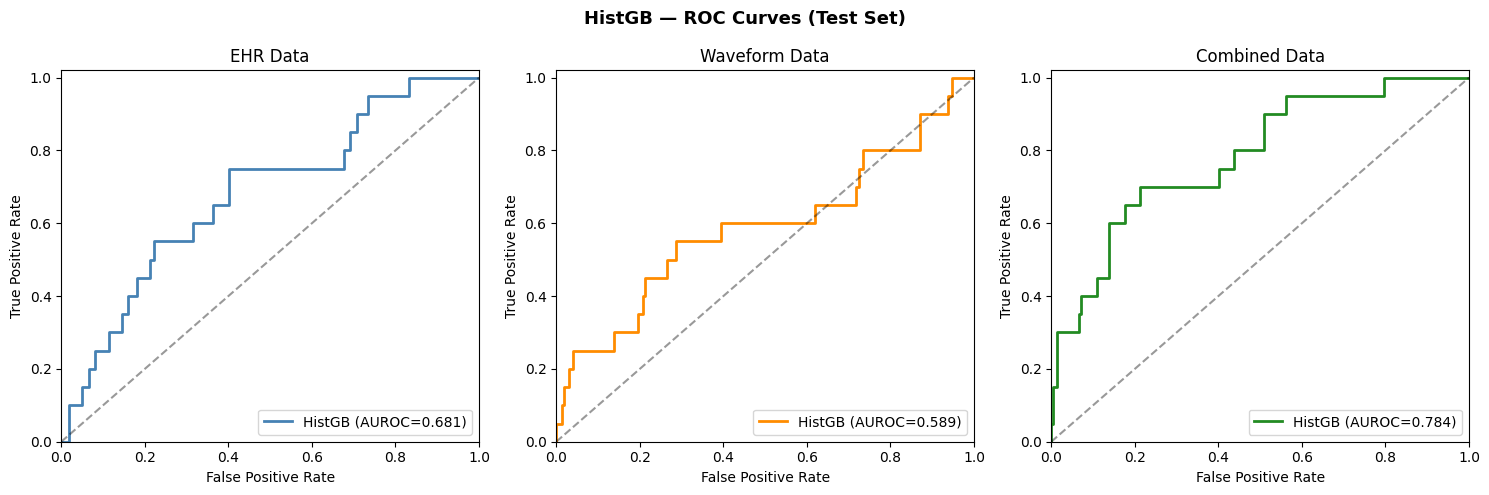

ROC curves saved → histgb_roc_curves.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — ROC Curves (test set, all 3 configurations)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('HistGB — ROC Curves (Test Set)', fontsize=13, fontweight='bold')

colors = {'EHR': 'steelblue', 'Waveform': 'darkorange', 'Combined': 'forestgreen'}

for ax, data_name in zip(axes, DATA_CONFIGS):
    r = results[data_name]
    _, _, y_tr, y_te = splits[data_name]
    fpr, tpr, _ = roc_curve(y_te, r['y_prob_te'])
    auroc = r['test']['AUROC']
    ax.plot(fpr, tpr, color=colors[data_name], lw=2,
            label=f'HistGB (AUROC={auroc:.3f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{data_name} Data')
    ax.legend(loc='lower right')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/histgb_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves saved → histgb_roc_curves.png')


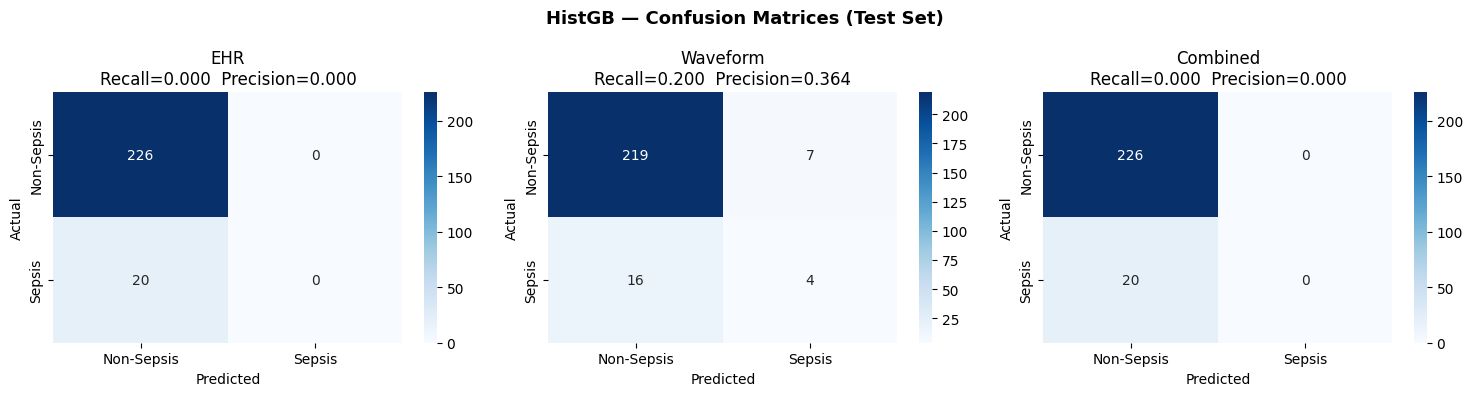

Confusion matrices saved → histgb_confusion_matrices.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Confusion Matrices (test set, all 3 configurations)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('HistGB — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, data_name in zip(axes, DATA_CONFIGS):
    r = results[data_name]
    _, _, y_tr, y_te = splits[data_name]
    cm = confusion_matrix(y_te, r['y_pred_te'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Sepsis','Sepsis'],
                yticklabels=['Non-Sepsis','Sepsis'])
    ax.set_title(f'{data_name}\n'
                 f'Recall={r["test"]["Recall"]:.3f}  Precision={r["test"]["Precision"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/histgb_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved → histgb_confusion_matrices.png')


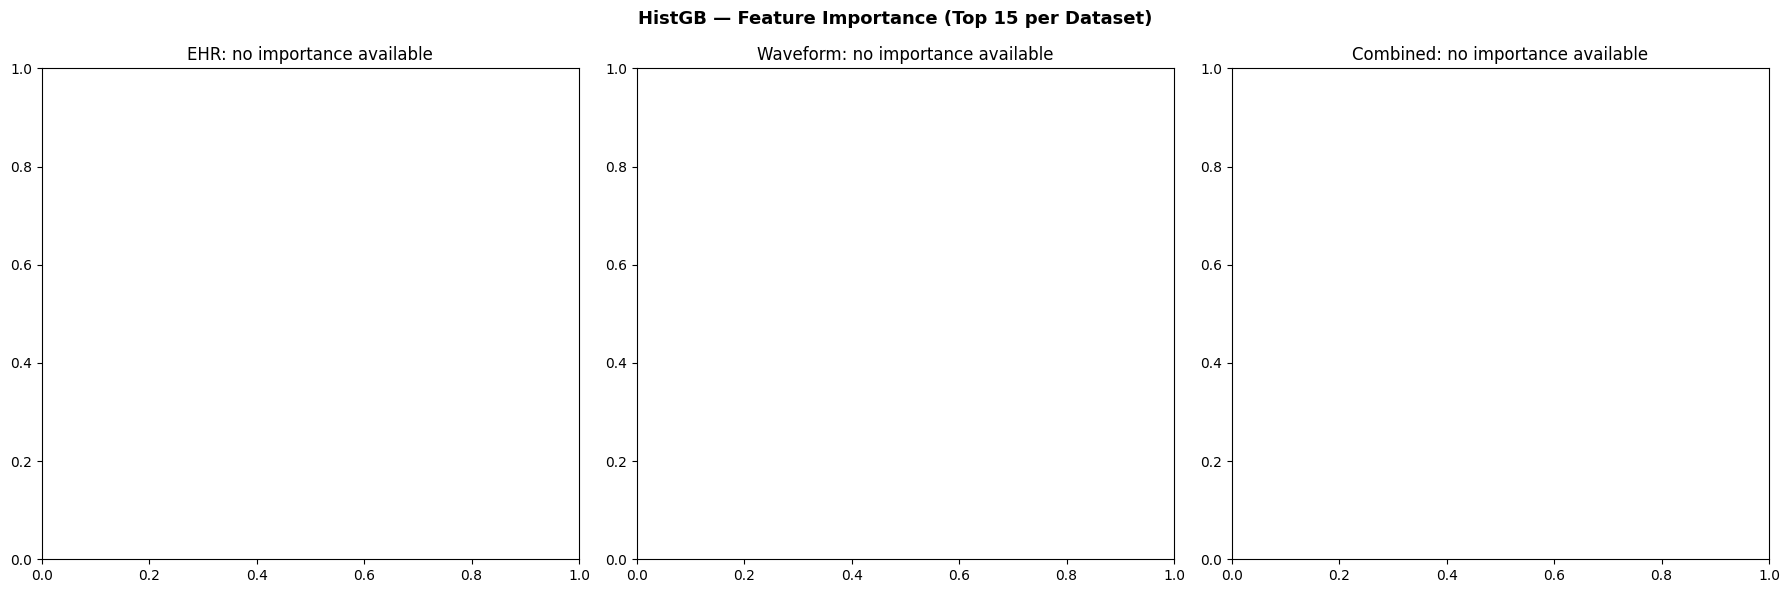

Feature importance plot saved → histgb_feature_importance.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Feature Importance (paper Section 2.8 & Figure 2)
# Paper: intrinsic feature importance scores from HistGB
# EHR top features: Lactate, Leukocyte (WBC), Temp
# Waveform top: RR_5, RR_4, Temp_5 (later-hour readings)
# Combined top: mean Temp, mean SBP
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('HistGB — Feature Importance (Top 15 per Dataset)', fontsize=13, fontweight='bold')

for ax, data_name in zip(axes, DATA_CONFIGS):
    r = results[data_name]
    if r['feat_imp'] is None:
        ax.set_title(f'{data_name}: no importance available')
        continue
    fi = pd.Series(r['feat_imp']).sort_values(ascending=False).head(15)
    fi_plot = fi.sort_values()
    fi_plot.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{data_name} Data\n(Top 15 features)')
    ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/histgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved → histgb_feature_importance.png')


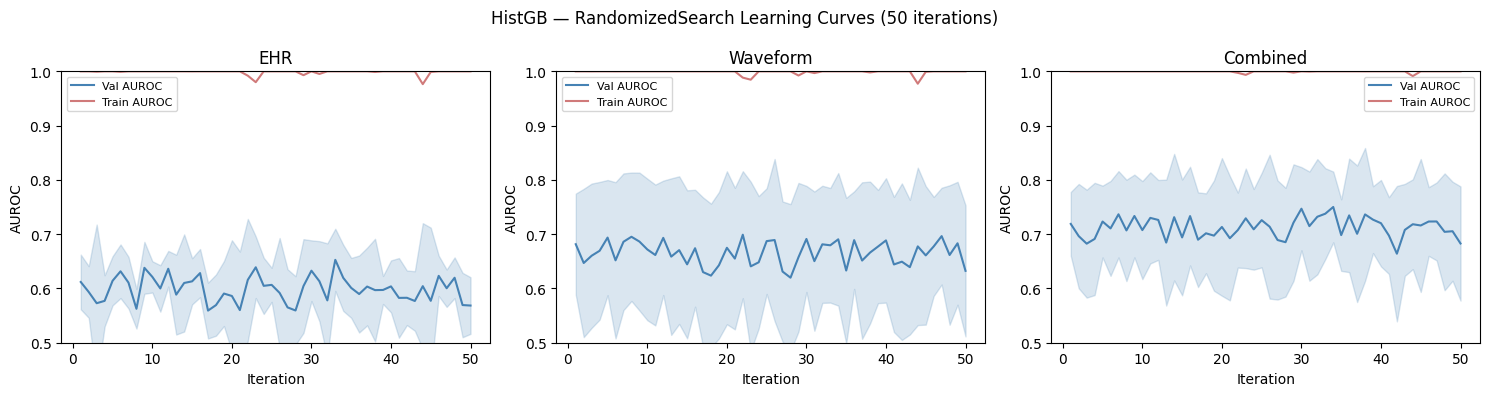

Learning curves saved → histgb_learning_curves.png


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Learning Curves (val AUROC across 50 RandomizedSearch iterations)
# Helps visualise hyperparameter search convergence and overfitting
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('HistGB — RandomizedSearch Learning Curves (50 iterations)', fontsize=12)

for ax, data_name in zip(axes, DATA_CONFIGS):
    log = results[data_name]['log_df']
    ax.plot(log['iter'], log['mean_val_auroc'],   label='Val AUROC',   color='steelblue')
    ax.plot(log['iter'], log['mean_train_auroc'],  label='Train AUROC', color='firebrick', alpha=0.6)
    ax.fill_between(log['iter'],
                    log['mean_val_auroc'] - log['std_val_auroc'],
                    log['mean_val_auroc'] + log['std_val_auroc'],
                    alpha=0.2, color='steelblue')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('AUROC')
    ax.set_title(f'{data_name}')
    ax.legend(fontsize=8)
    ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/histgb_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Learning curves saved → histgb_learning_curves.png')


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Save All Outputs
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# Results CSV
results_df.to_csv('/mnt/user-data/outputs/histgb_results.csv', index=False)

# Per-iteration logs
logs_combined = []
for data_name in DATA_CONFIGS:
    log = results[data_name]['log_df'].copy()
    log.insert(0, 'Dataset', data_name)
    logs_combined.append(log)
pd.concat(logs_combined, ignore_index=True).to_csv(
    '/mnt/user-data/outputs/histgb_iteration_logs.csv', index=False)

# Feature importances
fi_rows = []
for data_name in DATA_CONFIGS:
    fi = results[data_name]['feat_imp']
    if fi is not None:
        for feat, score in fi.items():
            fi_rows.append({'Dataset': data_name, 'Feature': feat, 'Importance': score})
if fi_rows:
    pd.DataFrame(fi_rows).to_csv(
        '/mnt/user-data/outputs/histgb_feature_importances.csv', index=False)

print('All outputs saved:')
for f in ['histgb_results.csv', 'histgb_iteration_logs.csv',
          'histgb_feature_importances.csv', 'histgb_eda.png',
          'histgb_learning_curves.png', 'histgb_roc_curves.png',
          'histgb_feature_importance.png', 'histgb_confusion_matrices.png']:
    print(f'  → {f}')


All outputs saved:
  → histgb_results.csv
  → histgb_iteration_logs.csv
  → histgb_feature_importances.csv
  → histgb_eda.png
  → histgb_learning_curves.png
  → histgb_roc_curves.png
  → histgb_feature_importance.png
  → histgb_confusion_matrices.png


Generating SHAP Summary Plot...


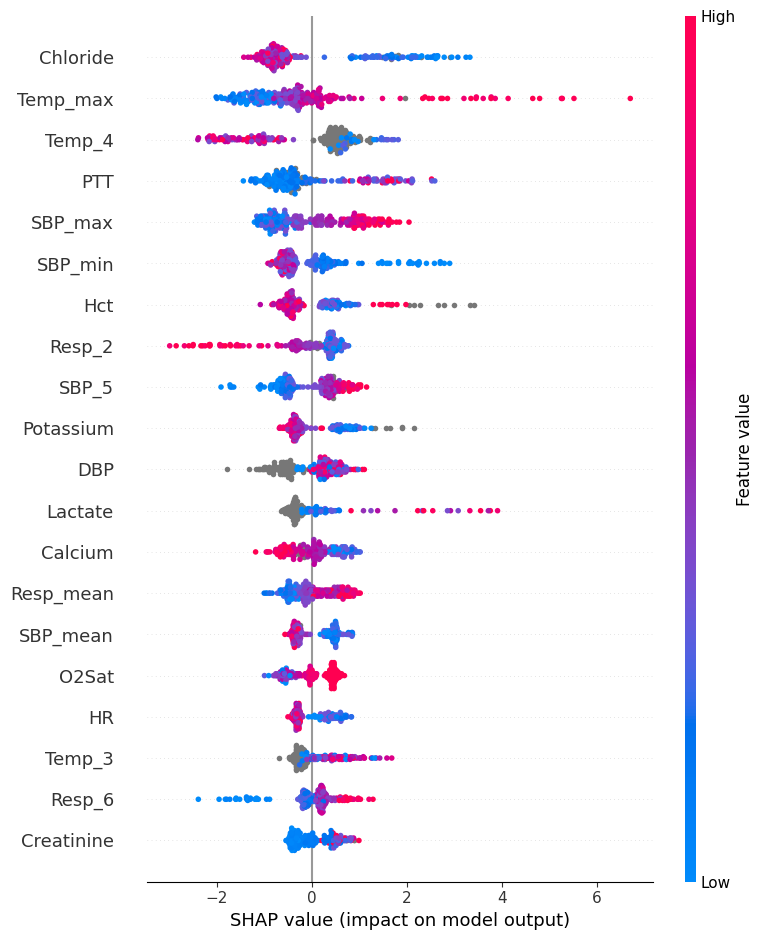

In [21]:
# NEW FINAL CELL — SHAP Interpretability (As seen in Paper Figure 2)
import shap

# Use the best HistGB model from your results
# Assuming your results dict stores the best estimator
best_model = results['Combined']['model']
X_sample = splits['Combined'][1] # Use the combined test set

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_sample)

## Additional XAI Technique 1: Permutation Feature Importance

While intrinsic feature importance from tree-based models (like the one used in `cell_17_fi`) provides a quick overview, Permutation Feature Importance offers a more robust measure. It works by shuffling the values of a single feature and observing how much the model's performance (e.g., AUROC) decreases. A larger decrease indicates a more important feature.

Calculating Permutation Feature Importance for the Combined model...


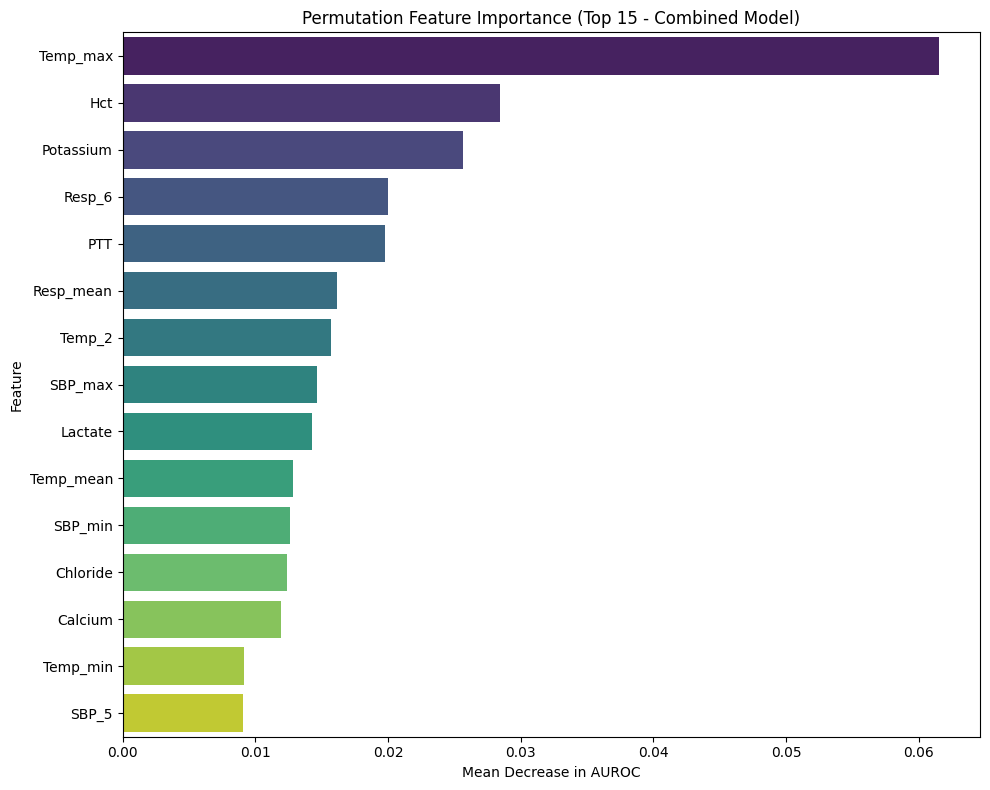

Permutation Feature Importance calculated and plotted.


In [22]:
from sklearn.inspection import permutation_importance

print("Calculating Permutation Feature Importance for the Combined model...")

best_model_combined = results['Combined']['model']
X_test_combined = splits['Combined'][1]
y_test_combined = splits['Combined'][3]

# Calculate permutation importance
perm_importance = permutation_importance(
    best_model_combined, X_test_combined, y_test_combined,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc'
)

# Organize results into a DataFrame
feature_names = X_test_combined.columns
perm_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values(by='Importance', ascending=False)

# Plot the top N features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=perm_imp_df.head(15), palette='viridis')
plt.title('Permutation Feature Importance (Top 15 - Combined Model)')
plt.xlabel('Mean Decrease in AUROC')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Permutation Feature Importance calculated and plotted.")

## Additional XAI Technique 2: Partial Dependence Plots (PDP)

Partial Dependence Plots (PDPs) show the marginal effect of one or two features on the predicted outcome of a machine learning model. A PDP illustrates whether the relationship between the target and a feature is linear, monotonic, or more complex. This helps to understand the average impact of a feature across all instances.

We will plot PDPs for a few of the most important features identified by SHAP or Permutation Importance.

Generating Partial Dependence Plots...


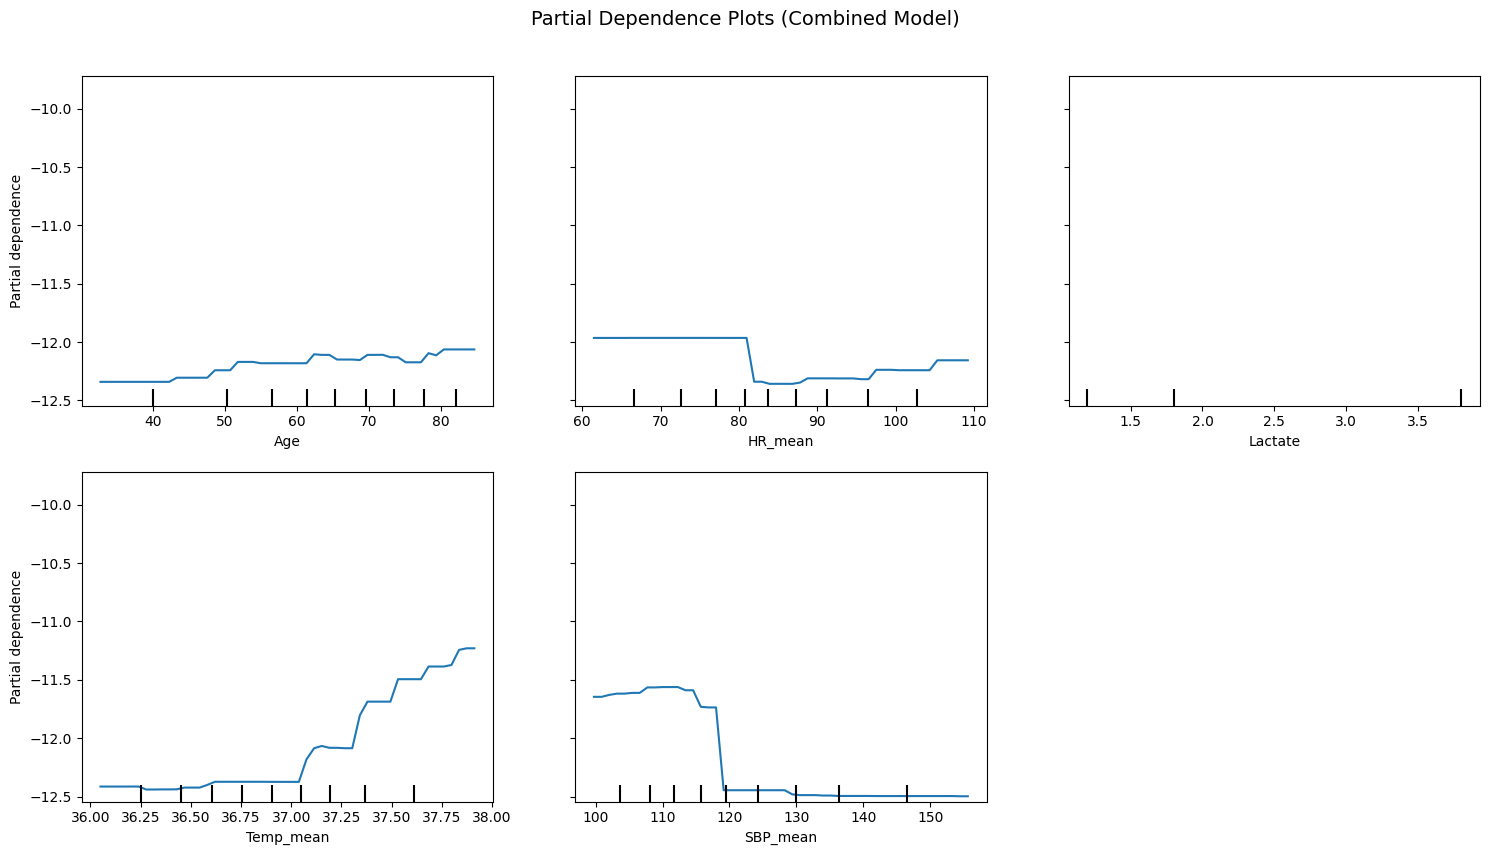

Partial Dependence Plots generated.


In [23]:
from sklearn.inspection import PartialDependenceDisplay

print("Generating Partial Dependence Plots...")

best_model_combined = results['Combined']['model']
X_combined = df_combined.drop(columns=[LABEL_COL])

# Select top features from the Permutation Importance or SHAP analysis
# For demonstration, let's pick a few that often show up as important
# (e.g., Age, HR_mean, Lactate, Temp_mean, SBP_mean)
# You might want to dynamically select based on `perm_imp_df` or `results['Combined']['feat_imp']`

top_features = ['Age', 'HR_mean', 'Lactate', 'Temp_mean', 'SBP_mean'] # Example features
# Filter for features actually present in the dataset
features_to_plot = [f for f in top_features if f in X_combined.columns]

if not features_to_plot:
    print("No relevant features found for PDP. Please check feature names.")
else:
    fig, ax = plt.subplots(figsize=(15, 5 * len(features_to_plot) / 3))
    PartialDependenceDisplay.from_estimator(
        best_model_combined, X_combined, features_to_plot,
        feature_names=X_combined.columns.tolist(),
        target=1, # Plotting for the positive class (SepsisLabel=1)
        grid_resolution=50,
        ax=ax
    )
    fig.suptitle('Partial Dependence Plots (Combined Model)', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Partial Dependence Plots generated.")

## Additional XAI Technique 3: LIME (Local Interpretable Model-agnostic Explanations)

LIME provides local explanations for individual predictions. Unlike global methods like SHAP or PDP, LIME focuses on explaining *why* a specific instance received its prediction. It does this by creating a simpler, interpretable model around the neighborhood of the instance being explained. This helps to build trust in individual predictions.

We will use LIME to explain a single instance from the test set of the 'Combined' model.

In [29]:
! pip install lime
import lime
import lime.lime_tabular

print("Generating LIME explanation for a single instance...")

best_model_combined = results['Combined']['model']
X_test_combined = splits['Combined'][1]
y_test_combined = splits['Combined'][3]

# LIME requires a prediction function that returns probabilities
predict_fn_histgb = lambda x: best_model_combined.predict_proba(x).astype(float)

# --- FIX START: More robust identification of varying features for LIME and disabling discretization ---
# Use the full X_combined (before train-test split) for more representative statistics for LIME
X_combined_full = df_combined.drop(columns=[LABEL_COL])

# Identify features that are not constant (standard deviation > epsilon and more than one unique value)
varying_features_global = []
for col in X_combined_full.columns:
    # Using a small epsilon to account for potential floating point inaccuracies
    if X_combined_full[col].std() > 1e-9 and X_combined_full[col].nunique() > 1:
        varying_features_global.append(col)

print(f"Number of varying features identified for LIME: {len(varying_features_global)}")

# Filter the full dataset to only include these varying features
X_train_for_lime_raw = X_combined_full[varying_features_global]
feature_names_for_lime = varying_features_global

# Impute missing values for LIME data (median imputation) to avoid NaN errors
# Create an imputer based on the 'training_data' for LIME
median_imputer = X_train_for_lime_raw.median()
X_train_for_lime_imputed = X_train_for_lime_raw.fillna(median_imputer)

# Select an instance from the test set, ensuring it also only contains varying features
instance_idx = 0
original_instance_id = X_test_combined.index[instance_idx]
instance_to_explain_raw = X_test_combined.loc[original_instance_id, varying_features_global].values

# Impute missing values for the instance to explain using the same imputer
# Ensure the instance is a Series/DataFrame for fillna to work with the median_imputer Series
instance_to_explain = pd.Series(instance_to_explain_raw, index=feature_names_for_lime).fillna(median_imputer).values

# --- FIX END ---

# Create a LIME explainer using the filtered and imputed training data
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_for_lime_imputed.values, # Use filtered and imputed full dataset for training data
    feature_names=feature_names_for_lime, # Use filtered feature names
    class_names=['Non-Sepsis', 'Sepsis'],
    mode='classification',
    discretize_continuous=False # Disable discretization to avoid truncnorm issues with low-variance features
)

print(f"Explaining instance with Patient_ID: {original_instance_id}")
print(f"Actual SepsisLabel: {y_test_combined.iloc[instance_idx]}")
print(f"Predicted Sepsis probability (Non-Sepsis, Sepsis): {predict_fn_histgb(instance_to_explain.reshape(1, -1))}")

# Generate explanation
explanation = explainer.explain_instance(
    data_row=instance_to_explain,
    predict_fn=predict_fn_histgb,
    num_features=min(10, len(feature_names_for_lime)) # Adjust num_features if less than 10 varying features
)

# Display the explanation in the notebook
explanation.show_in_notebook(show_all=False)

print("LIME explanation generated and displayed.")

Generating LIME explanation for a single instance...
Number of varying features identified for LIME: 63
Explaining instance with Patient_ID: 7130.0
Actual SepsisLabel: 0.0
Predicted Sepsis probability (Non-Sepsis, Sepsis): [[9.99999897e-01 1.03134224e-07]]


LIME explanation generated and displayed.
